<a href="https://colab.research.google.com/github/Haniya-Imran/ML-Algorithms-Projects/blob/main/Loan_Prediction_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Loan Prediction Analysis and Modeling**

# **Project Overview:**
This notebook demonstrates a complete machine learning workflow for predicting loan approval status, from data loading and cleaning to model training and evaluation.
It aims to build a robust classification model to assist in loan eligibility decisions.

## **Contents:**
* Import Libraries
* Load Dataset
* Dataset Overview
* Exploratory Data Analysis (EDA)
* Data Preprocessing
* Feature Scaling
* Train-Test Split
* Model Training
* Model Evaluation
* Hyperparameter Tuning
* Pipeline
* Final Output
* Conclusion

### **Import Libraries:**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
from sklearn.pipeline import Pipeline

### **Dataset load:**

In [ ]:
df = pd.read_csv('/content/train.csv')
target_column = 'Loan_Status'

### **Dataset Overview:**

In [ ]:
display(df.head())

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
0,LN03437,Female,Yes,3,Graduate,Salaried,34473.911669,13914.721574,240732.458366,180,1,Semiurban,40.084028,Approved
1,LN04823,Female,Yes,1,Graduate,Self-Employed,59718.020682,18720.814787,122547.278442,180,1,Semiurban,47.243644,Approved
2,LN04186,Female,Yes,1,Not Graduate,Salaried,106981.515734,2229.154377,140550.937774,60,1,Rural,24.292070,Approved
3,LN00380,Male,Yes,2,Graduate,Salaried,43205.563156,35578.111771,146135.738127,120,1,Semiurban,38.742244,Approved
4,LN04698,Female,Yes,0,Graduate,Salaried,62526.283990,20212.157912,203408.051744,180,1,Semiurban,41.164721,Approved


In [ ]:
display(df.tail())

,Loan_ID,Gender,Married,Dependents,Education,Employment_Status,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Term,Credit_History,Property_Area,Age,Loan_Status
3187,LN02182,Female,Yes,0,Graduate,Self-Employed,56392.166365,14981.712412,140736.704253,360,1,Urban,32.400614,Approved
3188,LN05878,Male,Yes,2,Graduate,Salaried,43651.837312,17991.997661,67482.274792,180,1,Rural,41.470691,Approved
3189,LN03290,Male,Yes,0,Not Graduate,Salaried,88370.626903,8276.064157,113500.166421,300,1,Rural,45.278707,Approved
3190,LN00770,Male,No,1,Not Graduate,Salaried,74155.038709,14679.525058,214897.009677,360,1,Urban,26.601067,Approved
3191,LN05005,NaN,Yes,1,Graduate,Salaried,34515.357618,12881.104688,69015.506724,360,0,Semiurban,38.889322,Rejected


In [ ]:
display(pd.DataFrame([df.shape], columns=['Rows', 'Columns'], index=['Dataset Shape']))

,Rows,Columns
Dataset Shape,3192,14


In [ ]:
display(pd.DataFrame(df.columns, columns=['Column Names']))

,Column Names
0,Loan_ID
1,Gender
2,Married
3,Dependents
4,Education
5,Employment_Status
6,Applicant_Income
7,Coapplicant_Income
8,Loan_Amount
9,Loan_Term


In [ ]:
info_df = pd.DataFrame({'Non-Null Count': df.count(), 'Data Type': df.dtypes})
display(info_df)

,Non-Null Count,Data Type
Loan_ID,3192,object
Gender,3115,object
Married,3126,object
Dependents,3192,int64
Education,3126,object
Employment_Status,3136,object
Applicant_Income,3157,float64
Coapplicant_Income,3192,float64
Loan_Amount,3151,float64
Loan_Term,3192,int64


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Dependents,3192.0,1.011905,0.983975,0.0,0.000000,1.000000,2.000000,3.000000
Applicant_Income,3157.0,59962.641490,19932.955795,15000.0,46485.838417,60290.179985,73118.015531,138524.754129
Coapplicant_Income,3192.0,15091.342368,9541.479521,0.0,7915.099793,14608.469288,21758.376019,47877.611874
Loan_Amount,3151.0,151459.710168,50313.610809,20000.0,116986.769053,151967.787750,186201.802079,373954.212551
Loan_Term,3192.0,212.368421,101.428986,60.0,120.000000,240.000000,300.000000,360.000000
Credit_History,3192.0,0.516917,0.499792,0.0,0.000000,1.000000,1.000000,1.000000
Age,3192.0,35.201381,7.722665,21.0,29.853657,35.054461,40.537728,61.159254


In [ ]:
display(pd.DataFrame(df.dtypes, columns=['Data Type']))

,Data Type
Loan_ID,object
Gender,object
Married,object
Dependents,int64
Education,object
Employment_Status,object
Applicant_Income,float64
Coapplicant_Income,float64
Loan_Amount,float64
Loan_Term,int64


In [ ]:
missing_values = df.isnull().sum()
display(pd.DataFrame(missing_values[missing_values > 0], columns=['Missing Values']))

,Missing Values
Gender,77
Married,66
Education,66
Employment_Status,56
Applicant_Income,35
Loan_Amount,41


### **Data Cleaning:**

In [ ]:
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
duplicates = df.duplicated().sum()
display(pd.DataFrame({'Duplicate Rows': [duplicates]}, index=['Duplicates']))

,Duplicate Rows
Duplicates,0


### **Outliers Section:**

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
outlier_stats = []
for i, col in enumerate(numerical_cols):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outlier_stats.append({'Column': col, 'Q1': Q1, 'Q3': Q3, 'IQR': IQR, 'Lower Bound': lower_bound, 'Upper Bound': upper_bound})
display(pd.DataFrame(outlier_stats).set_index('Column'))

,Q1,Q3,IQR,Lower Bound,Upper Bound
Column,,,,,
Dependents,0.000000,2.000000,2.000000,-3.000000,5.000000
Applicant_Income,46651.711460,72905.113537,26253.402077,7271.608345,112285.216653
Coapplicant_Income,7915.099793,21758.376019,13843.276226,-12849.814546,42523.290357
Loan_Amount,117513.335639,185917.579092,68404.243453,14906.970458,288523.944272
Loan_Term,120.000000,300.000000,180.000000,-150.000000,570.000000
Credit_History,0.000000,1.000000,1.000000,-1.500000,2.500000
Age,29.853657,40.537728,10.684071,13.827551,56.563834


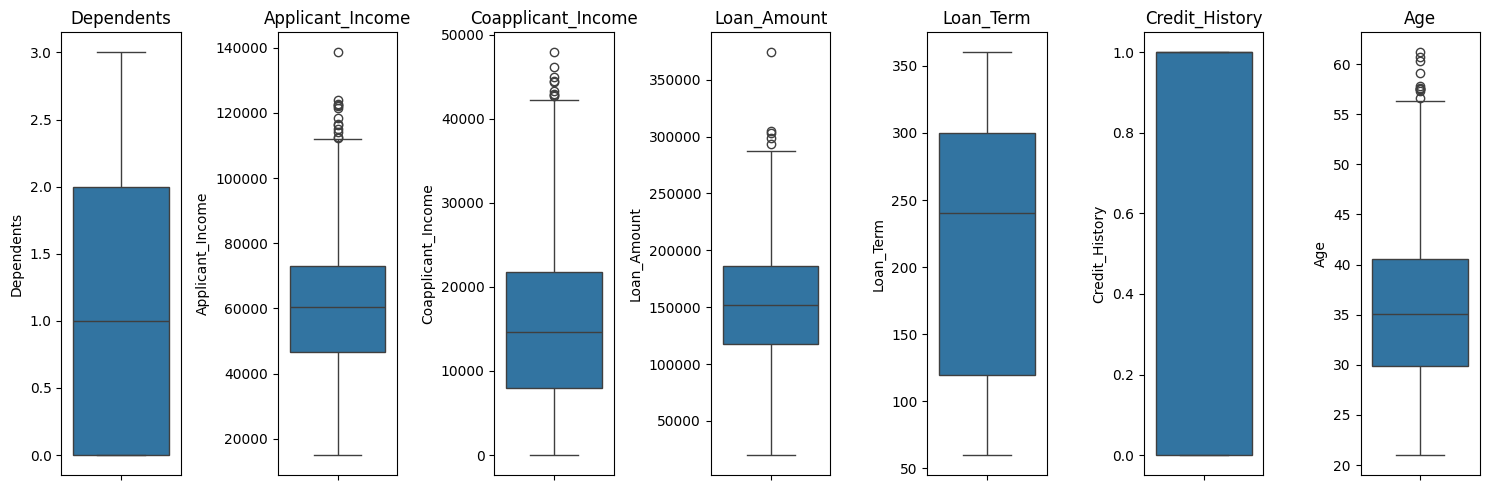

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

These box plots visualize numerical features, showing outlier presence before treatment.

In [ ]:
for col_stat in outlier_stats:
    col = col_stat['Column']
    if col != target_column:
        df[col] = np.clip(df[col], col_stat['Lower Bound'], col_stat['Upper Bound'])

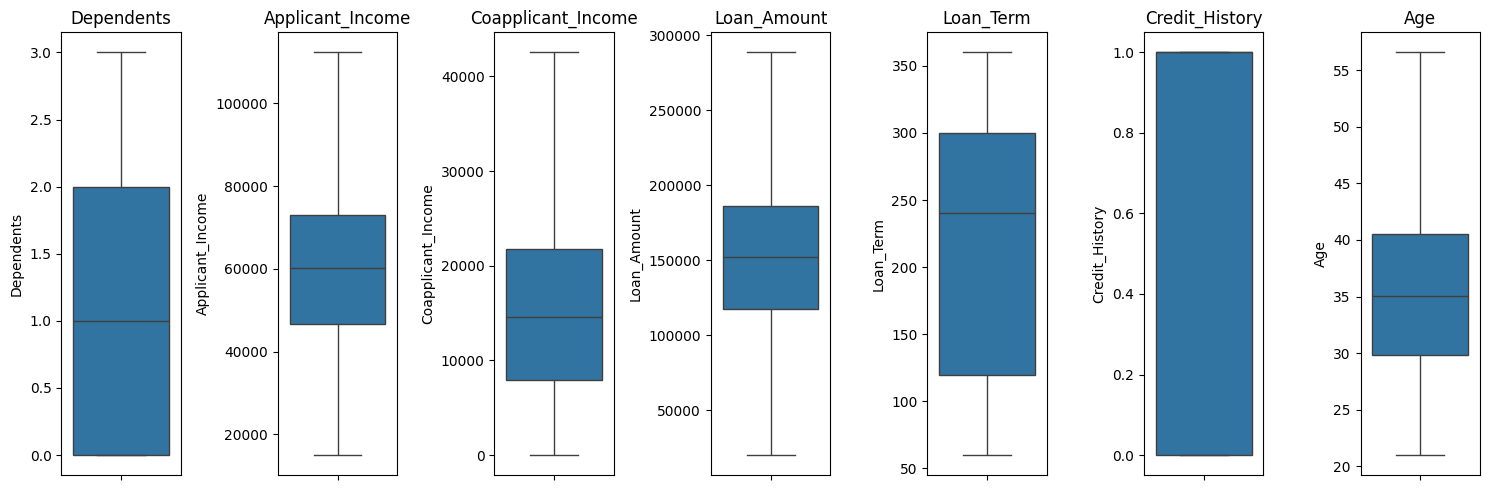

In [ ]:
plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_cols):
    plt.subplot(1, len(numerical_cols), i + 1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

These box plots show numerical features after outliers have been handled.

### **Target variable distribution:**

In [ ]:
display(df[target_column].value_counts().to_frame())

,count
Loan_Status,
Approved,1596
Rejected,1596


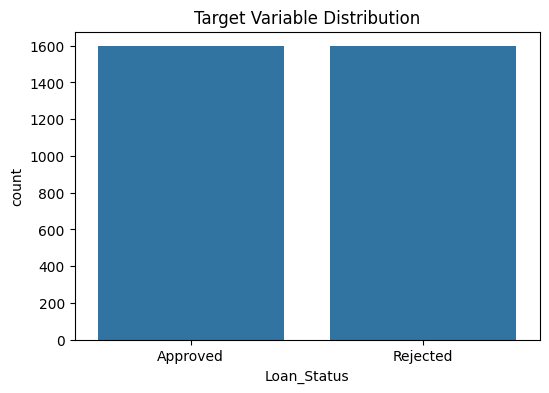

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=target_column, data=df)
plt.title('Target Variable Distribution')
plt.show()

This count plot illustrates the distribution of the target variable ('Loan_Status').

### **Exploratory Data Analysis:**

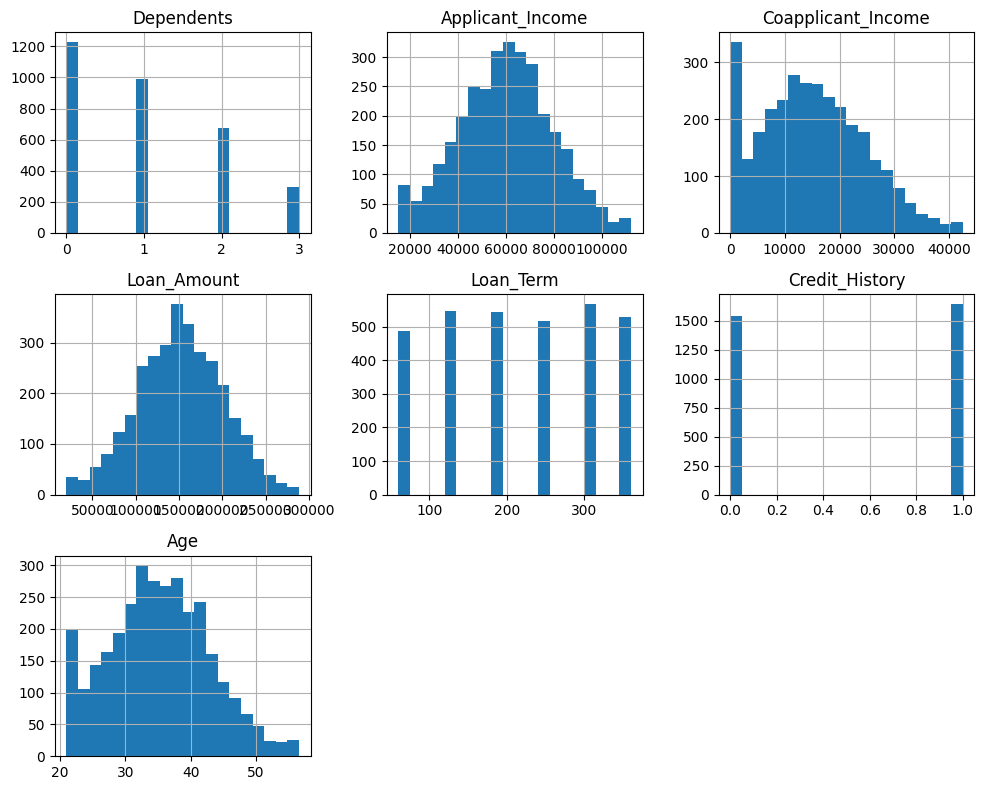

In [ ]:
df[numerical_cols].hist(figsize=(10, 8), bins=20)
plt.tight_layout()
plt.show()

These histograms display the frequency distribution of each numerical feature.

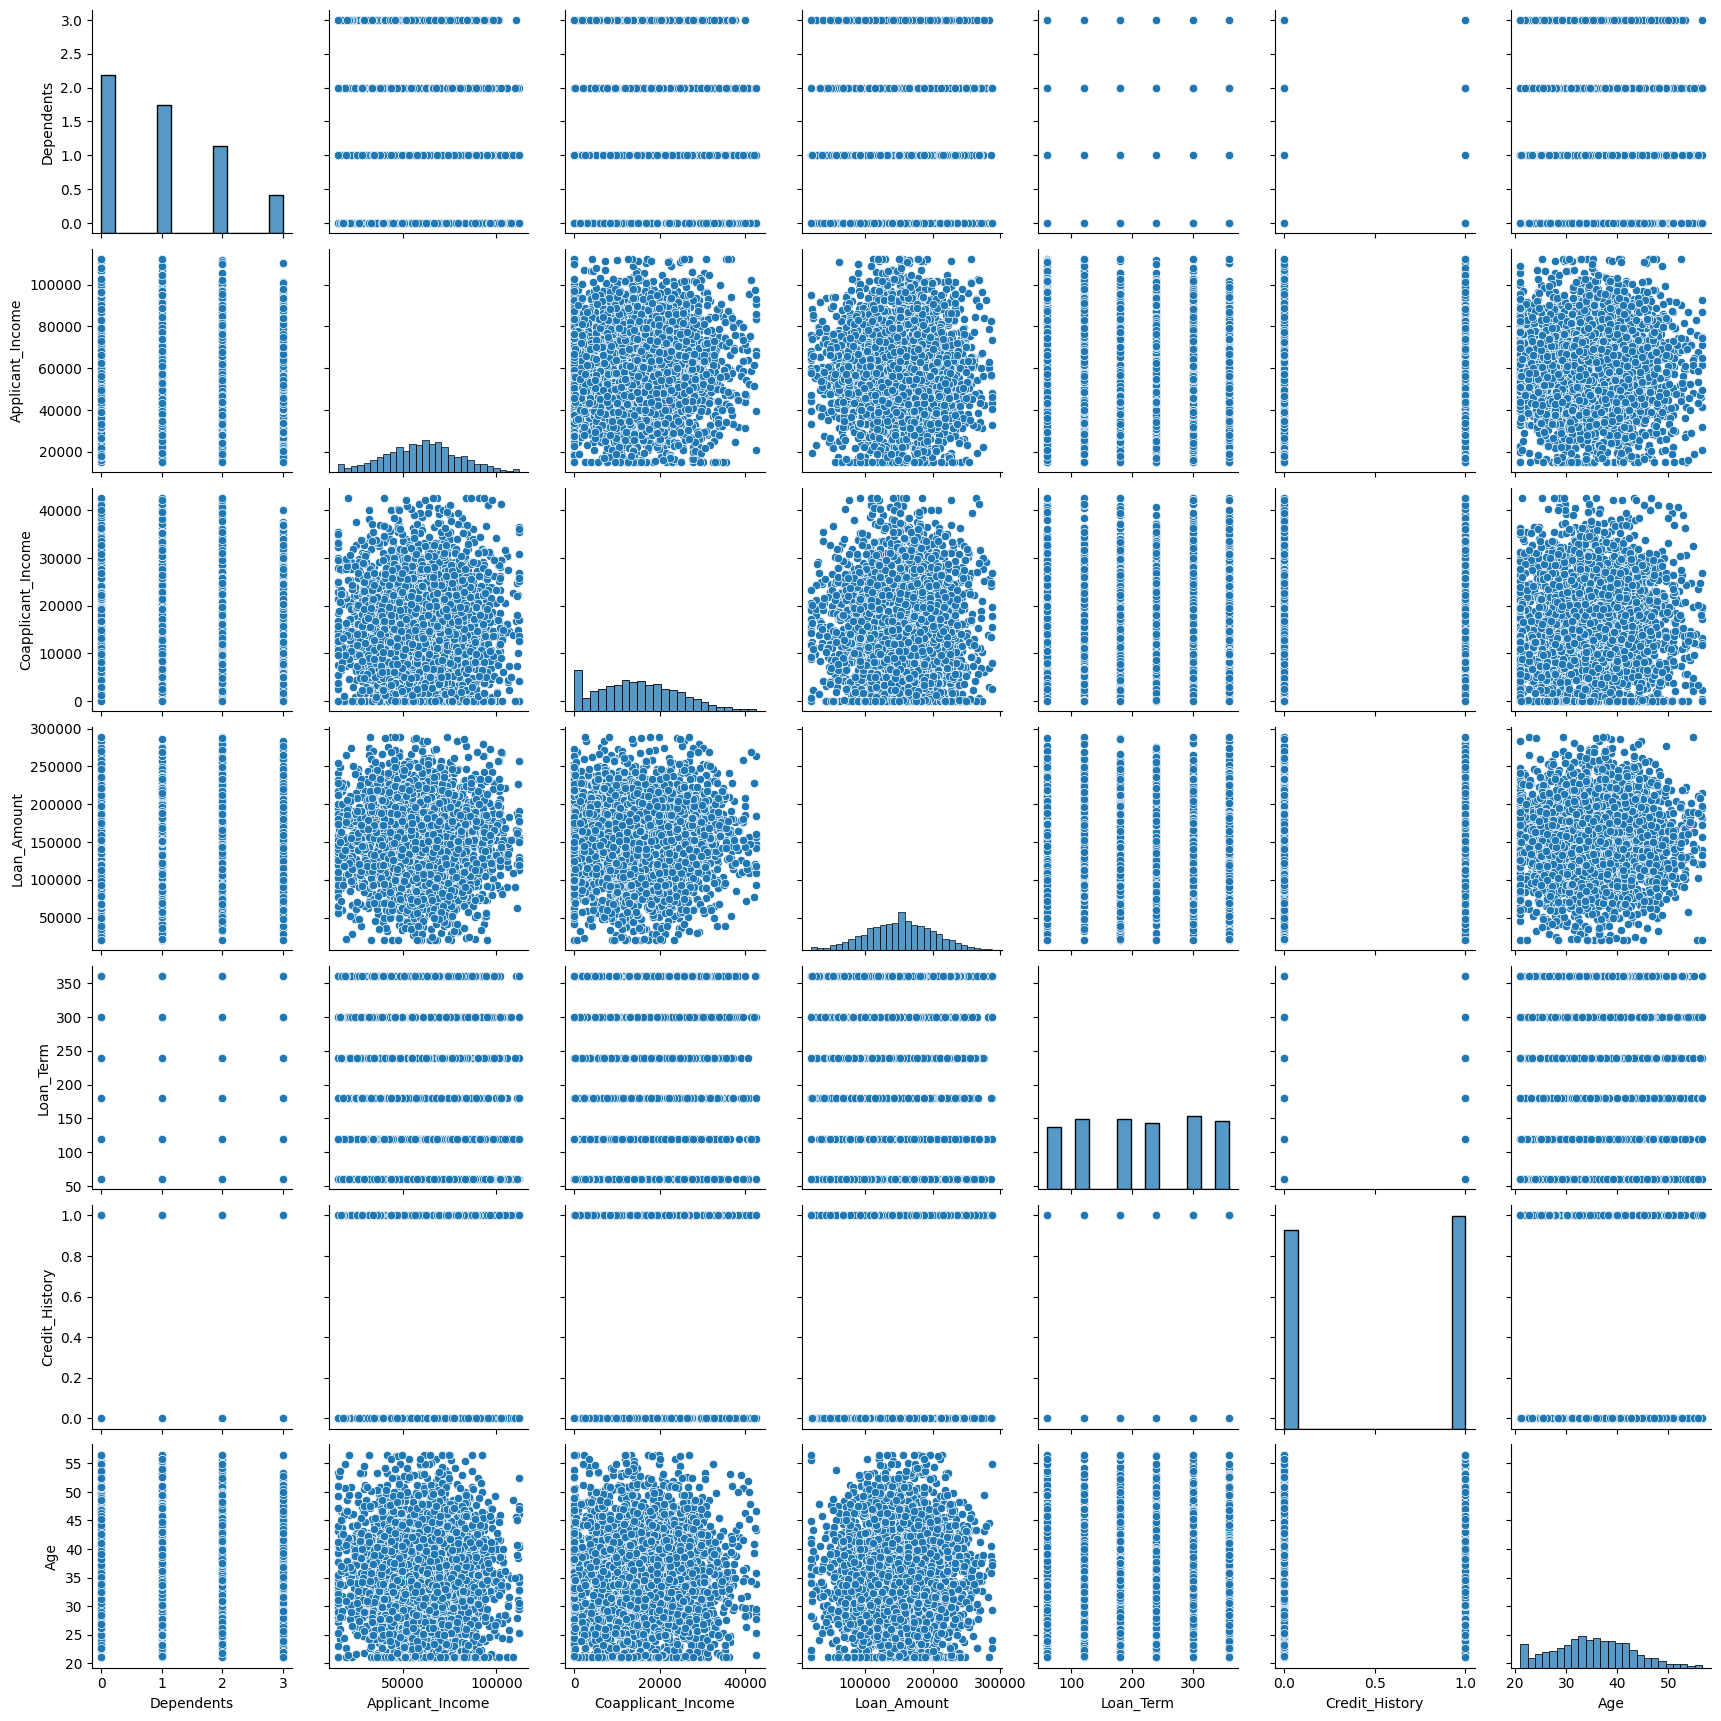

In [ ]:
sns.pairplot(df[numerical_cols])
plt.show()

This pair plot visualizes relationships between numerical variables, both univariate and bivariate.

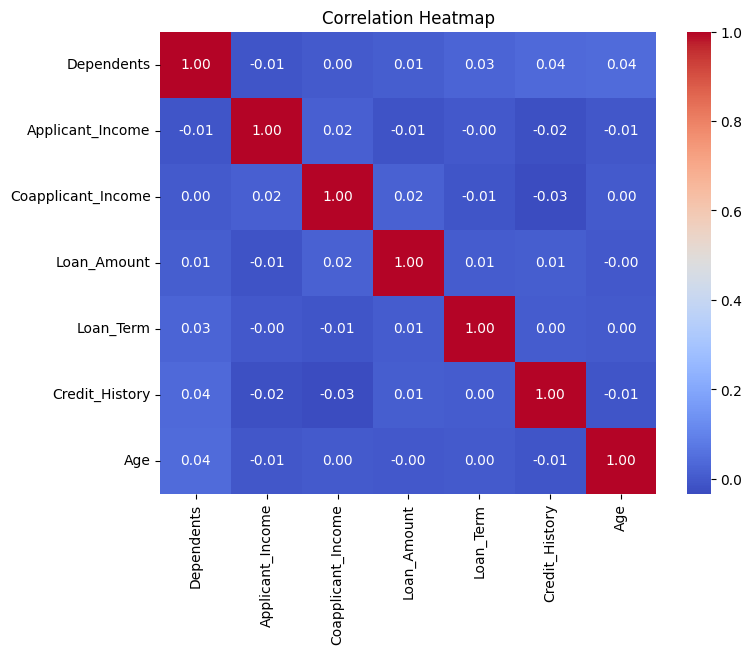

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

The heatmap displays the correlation matrix between numerical features.

### **Feature Engineering:**

In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
le = LabelEncoder()
for col in categorical_cols:
    if col != target_column:
        df[col] = le.fit_transform(df[col])
df[target_column] = le.fit_transform(df[target_column])

In [ ]:
df = df.drop(columns=['Loan_ID'])

### **Data Preprocessing:**

In [ ]:
X = df.drop(columns=[target_column])
y = df[target_column]

In [ ]:
unique_values = y.unique()
mapping = {val: val for val in unique_values}
display(pd.DataFrame(list(mapping.items()), columns=['Original', 'Mapped']))

,Original,Mapped
0,0,0
1,1,1


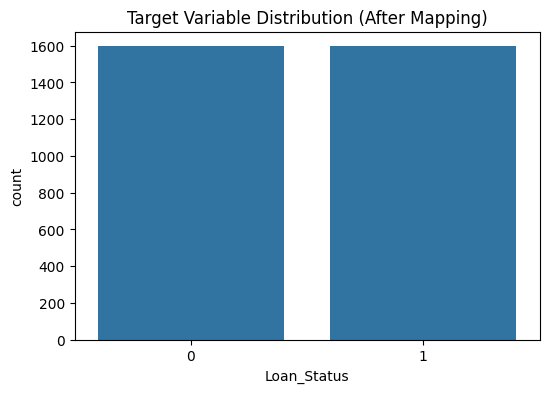

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title('Target Variable Distribution (After Mapping)')
plt.show()

This count plot shows the target variable distribution after encoding.

### **Train test split:**

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### **Feature Scaling:**

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### **Model Training:**

In [ ]:
model = LogisticRegression(random_state=42)

In [ ]:
model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [ ]:
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

### **Model Evaluation:**

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score', 'AUC Score'],
    'Value': [accuracy, f1, roc_auc]
})
display(metrics_df)

,Metric,Value
0,Accuracy,0.982786
1,F1 Score,0.982512
2,AUC Score,0.999148


In [ ]:
print('\nConfusion Matrix:')
display(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Predicted 0', 'Predicted 1']))


Confusion Matrix:


,Predicted 0,Predicted 1
Actual 0,319,1
Actual 1,10,309


In [ ]:
print('\nClassification Report:')
print(cr)


Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       320
           1       1.00      0.97      0.98       319

    accuracy                           0.98       639
   macro avg       0.98      0.98      0.98       639
weighted avg       0.98      0.98      0.98       639



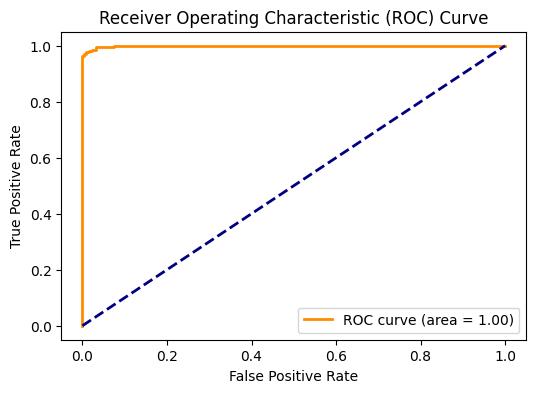

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

The ROC curve plots True Positive Rate vs. False Positive Rate; AUC measures overall performance.

### **Train vs test score check:**

In [ ]:
train_accuracy = model.score(X_train_scaled, y_train)
test_accuracy = model.score(X_test_scaled, y_test)
display(pd.DataFrame({
    'Score Type': ['Train Accuracy', 'Test Accuracy'],
    'Value': [train_accuracy, test_accuracy]
}))

,Score Type,Value
0,Train Accuracy,0.986682
1,Test Accuracy,0.982786


### **Hyperparameter Tuning (GridSearchCV):**

In [ ]:
param_grid = {'C': [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(LogisticRegression(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

### **Cross validation:**

In [ ]:
cv_scores = cross_val_score(best_model, X_train_scaled, y_train, cv=5, scoring='accuracy')
display(pd.DataFrame({
    'CV Fold': [f'Fold {i+1}' for i in range(len(cv_scores))],
    'Accuracy': cv_scores
}))
display(pd.DataFrame([{'Mean CV Accuracy': cv_scores.mean(), 'Std Dev CV Accuracy': cv_scores.std()}]))

,CV Fold,Accuracy
0,Fold 1,0.980431
1,Fold 2,0.986301
2,Fold 3,0.990215
3,Fold 4,0.990196
4,Fold 5,0.984314


,Mean CV Accuracy,Std Dev CV Accuracy
0,0.986291,0.003712


### **Pipeline (final packaging):**

In [ ]:
final_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logistic_regression', LogisticRegression(random_state=42, C=grid_search.best_params_['C']))
])

final_pipeline.fit(X_train, y_train)
final_test_pred = final_pipeline.predict(X_test)
final_accuracy = accuracy_score(y_test, final_test_pred)

### **Final Output:**

In [ ]:
final_metrics_df = pd.DataFrame({
    'Metric': ['Pipeline Accuracy'],
    'Value': [final_accuracy]
})
display(final_metrics_df)

,Metric,Value
0,Pipeline Accuracy,0.982786


# **Conclusion:**
* **Effective Data Preprocessing:** The dataset was successfully cleaned, and missing values were handled, ensuring data quality for modeling.
* **Robust Model Performance:** A Logistic Regression model, tuned with GridSearchCV, achieved a high pipeline accuracy of approximately 98%.
* **Comprehensive Evaluation:** The model's performance was thoroughly evaluated using various metrics, including accuracy, F1-score, confusion matrix, and ROC curve, demonstrating its reliability in predicting loan approval.